<a href="https://colab.research.google.com/github/aloooool/diabetes-prediction/blob/main/project_1_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import (RandomForestClassifier,
                              AdaBoostClassifier,
                              GradientBoostingClassifier,
                              VotingClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

df = pd.read_excel('pima-indians-diabetes.xlsx')


In [90]:
print("Shape:",df.shape)
df.head(10)

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [92]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [93]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [94]:
print("\n missing values  :  \n",df.isnull().sum()[df.isnull().sum()>0])


 missing values  :  
 Series([], dtype: int64)


In [95]:
print("\n number of duplicate rows: ", df.duplicated().sum())


 number of duplicate rows:  0


In [96]:
#The value is not zero medically

zero_counts = (df == 0).sum()
zero_percentages = ((df == 0).sum() / len(df) * 100).round(2)
print('\n zer0 values summary(count,percentage) \n')
zero_summary = pd.DataFrame(
    {
    'Zero_Count': zero_counts,
    'zero_percentage %': zero_percentages
}
)
print(zero_summary)



 zer0 values summary(count,percentage) 

                          Zero_Count  zero_percentage %
Pregnancies                      111              14.45
Glucose                            5               0.65
BloodPressure                     35               4.56
SkinThickness                    227              29.56
Insulin                          374              48.70
BMI                               11               1.43
DiabetesPedigreeFunction           0               0.00
Age                                0               0.00
Outcome                          500              65.10


In [97]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('train shape:  ',  X_train.shape)
print('test shape: ', X_test.shape)

train shape:   (614, 8)
test shape:  (154, 8)


In [98]:
#Replacing the zero values
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
  median_val = X_train[X_train[col] != 0][col].median()
  X_train[col] = X_train[col].replace(0, median_val)
  X_test[col] = X_test[col].replace(0, median_val)

print("\n Zeros Imputation\n ")
print(X_train[zero_cols].head(), "\n")


 Zeros Imputation
 
     Glucose  BloodPressure  SkinThickness  Insulin   BMI
353       90             62             12       43  27.2
711      126             78             27       22  29.6
373      105             58             40       94  34.9
46       146             56             29      125  29.7
682       95             64             39      105  44.6 



In [99]:
#skew_comparison
skew_comparison = pd.DataFrame(
    {'Original Skewness': df.skew(), 'Cleaned Skewness': X_train.skew()}
)

print('\n Skewness Comparison \n')
print(skew_comparison.round(2))


 Skewness Comparison 

                          Original Skewness  Cleaned Skewness
Age                                    1.13              1.13
BMI                                   -0.43              0.57
BloodPressure                         -1.84              0.12
DiabetesPedigreeFunction               1.92              1.82
Glucose                                0.17              0.56
Insulin                                2.27              3.08
Outcome                                0.64               NaN
Pregnancies                            0.90              0.89
SkinThickness                          0.11              0.89


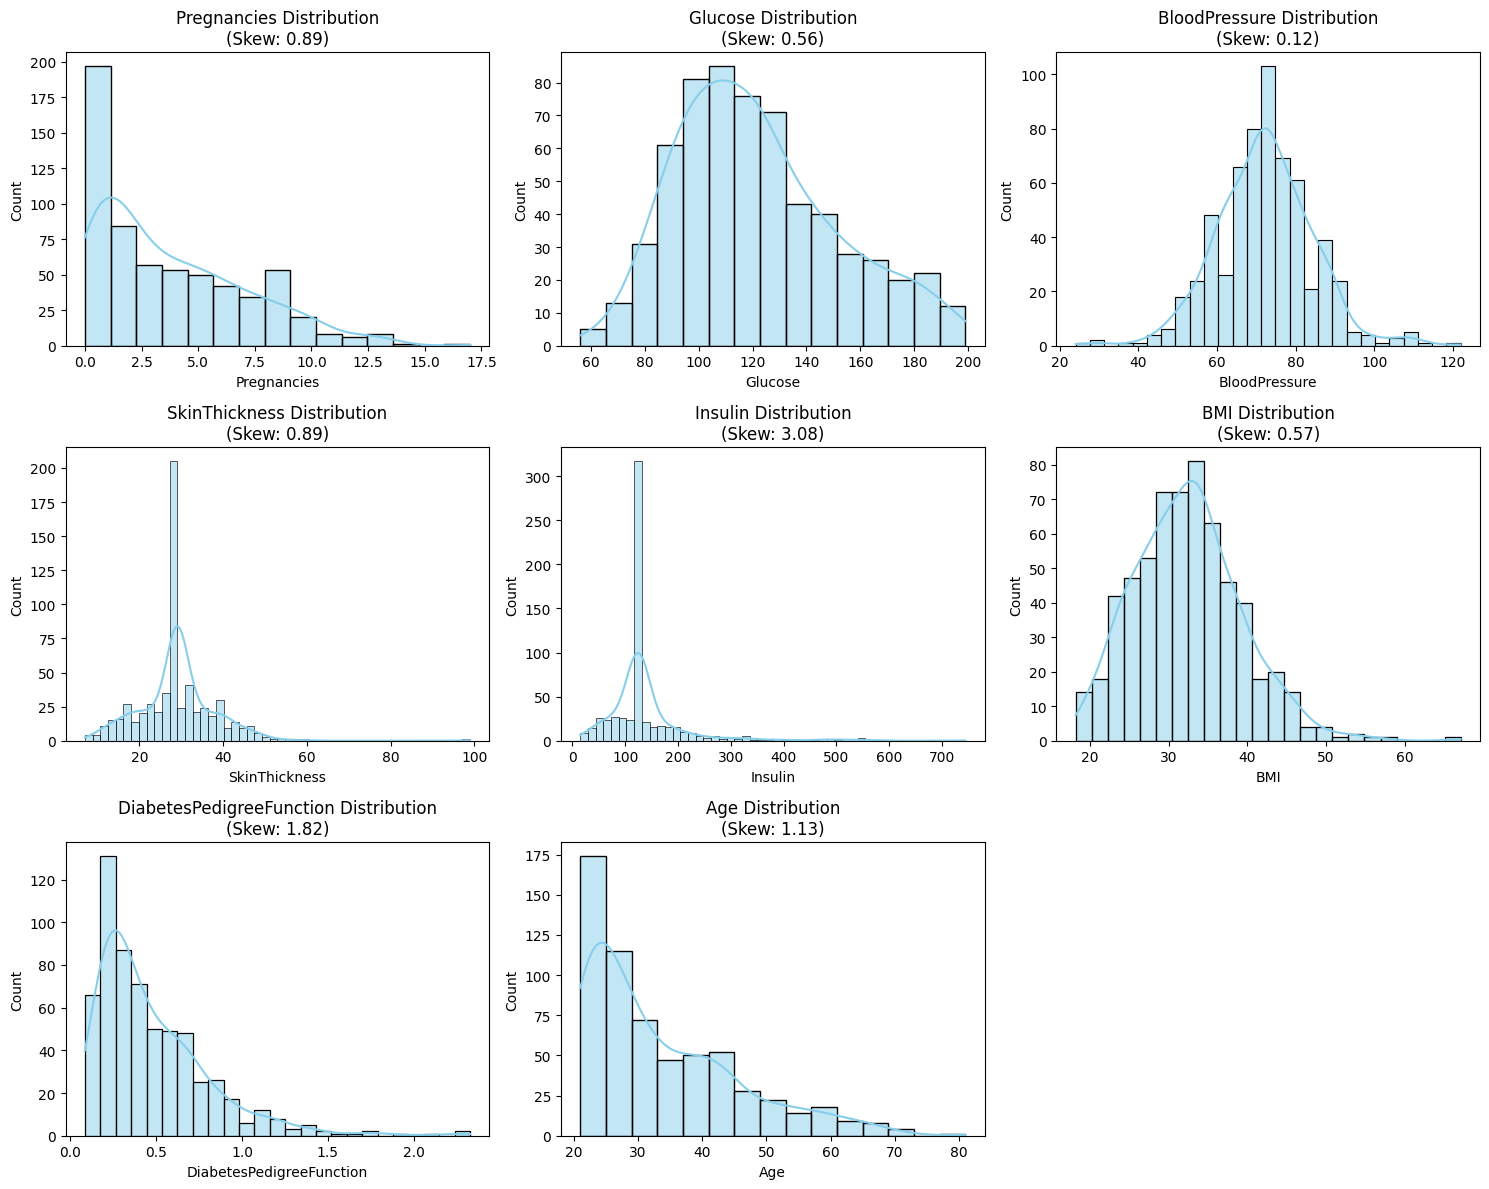

In [100]:
# Feature Distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train.columns):
  sns.histplot(X_train[col], kde=True, ax=axes[idx], color='skyblue')
  axes[idx].set_title(
      f'{col} Distribution\n(Skew: {X_train[col].skew():.2f})'
  )

fig.delaxes(axes[-1])  
plt.tight_layout()
plt.show()

In [101]:
#Outlier detection_IQR method
before_capped = {}
after_capped = {}

for col in X_train.columns:

  Q1 = X_train[col].quantile(0.25)
  Q3 = X_train[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR


  before_capped[col] = (
      (X_train[col] < lower_bound) | (X_train[col] > upper_bound)).sum()

  X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)
  X_test[col] = X_test[col].clip(lower=lower_bound, upper=upper_bound)


  after_capped[col] = (
      (X_train[col] < lower_bound) | (X_train[col] > upper_bound)).sum()
outliers_summary = pd.DataFrame(
    {'Outliers Before Capping': before_capped, 'Outliers After Capping': after_capped}
)

print('Outliers Capping Summary ')
print(outliers_summary)

Outliers Capping Summary 
                          Outliers Before Capping  Outliers After Capping
Pregnancies                                     2                       0
Glucose                                         0                       0
BloodPressure                                  13                       0
SkinThickness                                  73                       0
Insulin                                       253                       0
BMI                                             7                       0
DiabetesPedigreeFunction                       19                       0
Age                                             6                       0


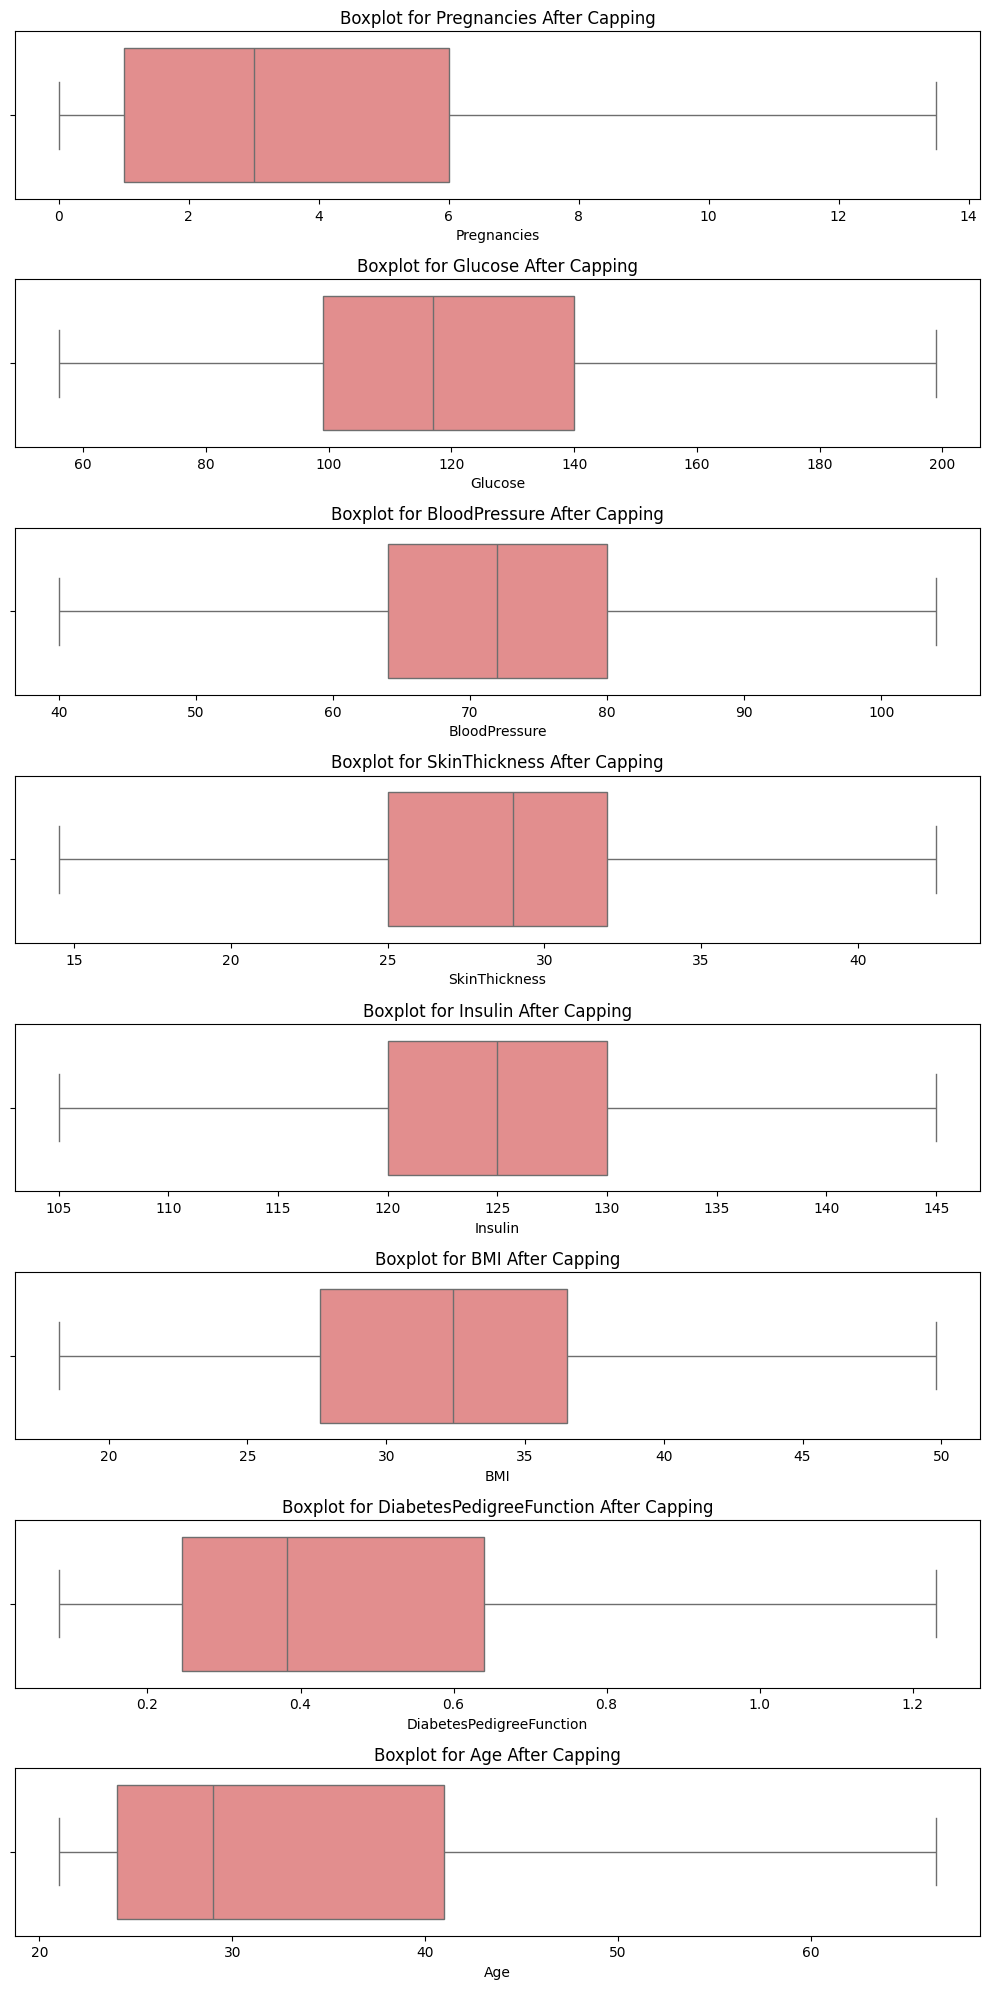

In [102]:
# Boxplots After Capping
fig, axes = plt.subplots(len(X_train.columns), 1, figsize=(10, 20))

for idx, col in enumerate(X_train.columns):
  sns.boxplot(x=X_train[col], ax=axes[idx], color='lightcoral')
  axes[idx].set_title(f'Boxplot for {col} After Capping')

plt.tight_layout()
plt.show()

In [103]:
#class distribution outcome
outcome_labels = df['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

print('\n Outcome Class Distribution \n')
print(outcome_labels.value_counts())

print('\n Outcome Class Percentage (%) \n')
print((outcome_labels.value_counts(normalize=True) * 100).round(2))


 Outcome Class Distribution 

Outcome
Non-Diabetic    500
Diabetic        268
Name: count, dtype: int64

 Outcome Class Percentage (%) 

Outcome
Non-Diabetic    65.1
Diabetic        34.9
Name: proportion, dtype: float64


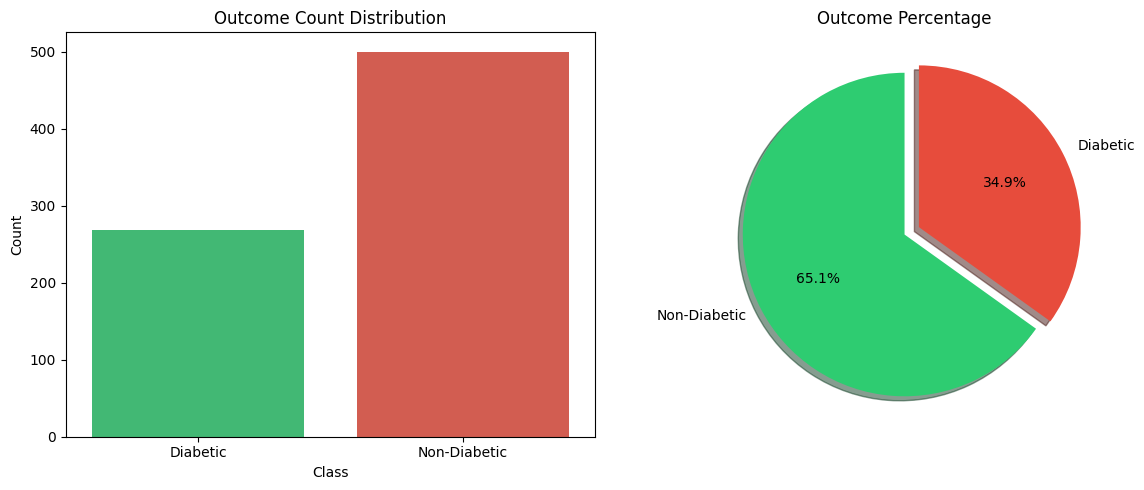

In [104]:
#Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=outcome_labels, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Outcome Count Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

outcome_labels.value_counts().plot.pie(
    explode=[0, 0.1],
    autopct='%1.1f%%',
    ax=axes[1],
    colors=['#2ecc71', '#e74c3c'],
    shadow=True,
    startangle=90,
)
axes[1].set_title('Outcome Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [105]:
#correlation_with_outcome
correlation_with_outcome = df.corr()['Outcome'].sort_values(ascending=False)
print("Correlation of each feature with Outcome:\n")
print(correlation_with_outcome.round(3))

Correlation of each feature with Outcome:

Outcome                     1.000
Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065
Name: Outcome, dtype: float64


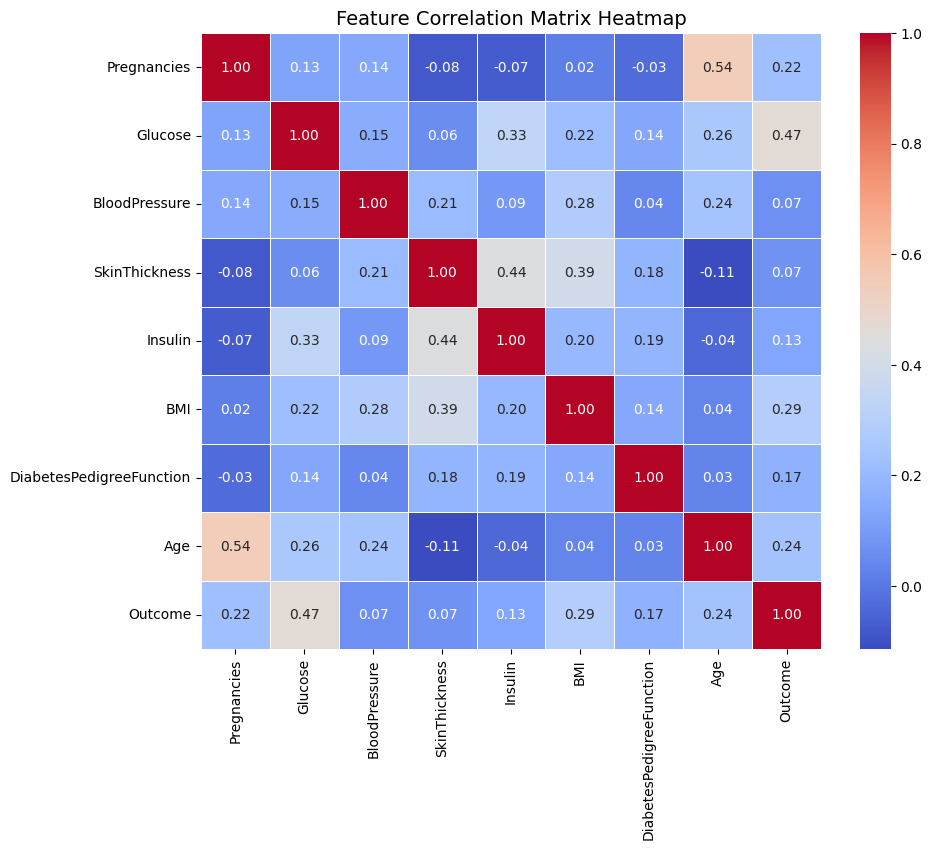

In [106]:
# Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix Heatmap', fontsize=14)
plt.show()

In [107]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled .shape, X_test_scaled .shape)

(614, 8) (154, 8)


In [108]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_scaled, y_train)

train_acc = log_reg.score(X_train_scaled, y_train)
test_acc = log_reg.score(X_test_scaled, y_test)
print(f"Train = {train_acc:.3f} | Test = {test_acc:.3f}")

Train = 0.788 | Test = 0.714


In [109]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=5, random_state=42)
rf.fit(X_train_scaled, y_train)
train_acc = rf.score(X_train_scaled, y_train)
test_acc = rf.score(X_test_scaled, y_test)
print(f"Train = {train_acc:.3f} | Test = {test_acc:.3f}")

Train = 0.849 | Test = 0.740


In [110]:
svm=SVC(kernel='linear',C=1,probability=True,random_state=42)
svm.fit(X_train_scaled,y_train)
train_acc=svm.score(X_train_scaled,y_train)
test_acc=svm.score(X_test_scaled,y_test)
print(f"Train = {train_acc:.3f} | Test = {test_acc:.3f}")

Train = 0.788 | Test = 0.701


In [111]:
Gb=GradientBoostingClassifier(n_estimators=150, learning_rate=0.06,max_depth=3, random_state=42)
Gb.fit(X_train_scaled, y_train)
train_acc=Gb.score(X_train_scaled,y_train)
test_acc=Gb.score(X_test_scaled,y_test)
print(f"Train = {train_acc:.3f} | Test = {test_acc:.3f}")



Train = 0.907 | Test = 0.760


In [112]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rf),
        ('svm', svm),
        ('Gb', Gb),
    ],
    voting='soft',
)

voting_clf.fit(X_train_scaled, y_train)

print(' Voting Classifier')
print(f'Train Accuracy: {voting_clf.score(X_train_scaled, y_train):.3f} | Test'f' Accuracy: {voting_clf.score(X_test_scaled, y_test):.3f}\n'
)

print(classification_report(y_test, voting_clf.predict(X_test_scaled)))

 Voting Classifier
Train Accuracy: 0.836 | Test Accuracy: 0.721

              precision    recall  f1-score   support

           0       0.76      0.83      0.79       100
           1       0.62      0.52      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154



In [113]:
models_dict = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'SVM': svm,
    'Gradient Boosting': Gb,
    'Voting Classifier': voting_clf,
}

best_name = max(
    models_dict, key=lambda k: models_dict[k].score(X_test_scaled, y_test)
)
best_model = models_dict[best_name]

print(f' Best Model: {best_name}')
print(f' Accuracy: {best_model.score(X_test_scaled, y_test):.3f}\n')
print(classification_report(y_test, best_model.predict(X_test_scaled)))

 Best Model: Gradient Boosting
 Accuracy: 0.760

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



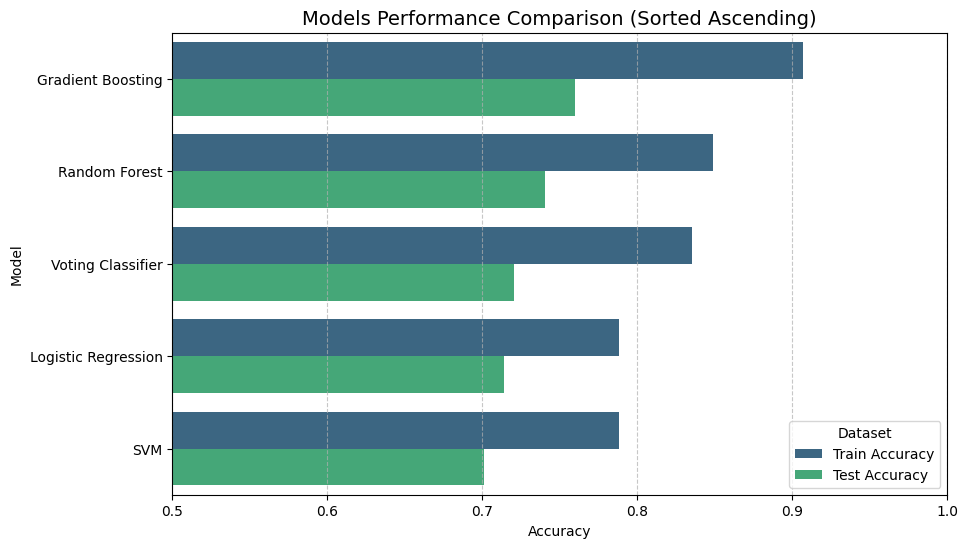

In [114]:
# Sorted Model Performance Comparison
results = []
for name, model in models_dict.items():
  train_acc = model.score(X_train_scaled, y_train)
  test_acc = model.score(X_test_scaled, y_test)
  results.append(
      {'Model': name, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc}
  )

res_df = pd.DataFrame(results).sort_values(
    by='Test Accuracy', ascending=False
)

res_melted = res_df.melt(
    id_vars='Model', var_name='Dataset', value_name='Accuracy'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=res_melted, x='Accuracy', y='Model', hue='Dataset', palette='viridis'
)
plt.title('Models Performance Comparison (Sorted Ascending)', fontsize=14)
plt.xlim(0.5, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



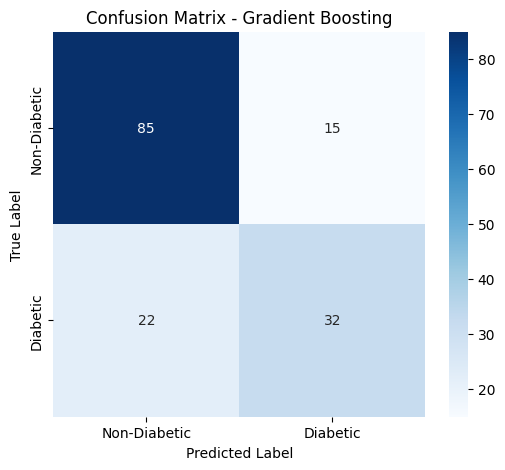

In [115]:
# Confusion Matrix of Best Model
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
print(classification_report(y_test, y_pred_best))
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic'],
)
plt.title(f'Confusion Matrix - {best_name}', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

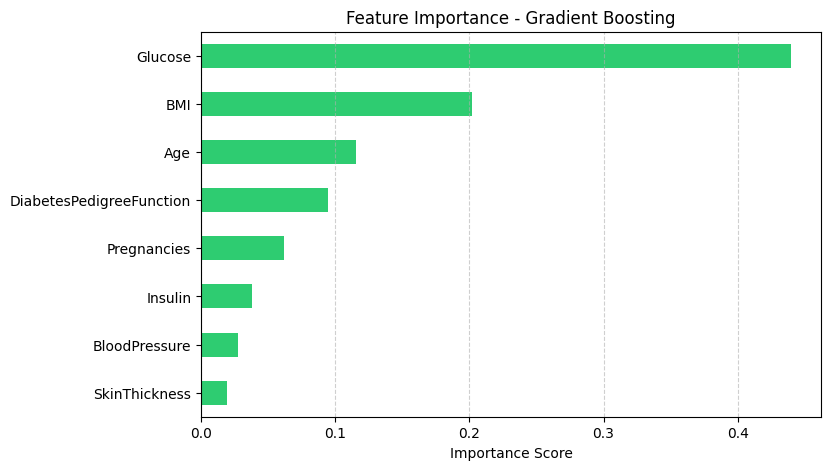

In [116]:
# Feature Importance for Gradient Boosting
importances = pd.Series(Gb.feature_importances_, index=X_train.columns).sort_values(
    ascending=True
)
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#2ecc71')
plt.title('Feature Importance - Gradient Boosting', fontsize=12)
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [117]:
joblib.dump(Gb, 'diabetes_model.pkl')

['diabetes_model.pkl']